# 03 – Forecasting Models: Day-Ahead Forecasts

Dieses Notebook erzeugt die Forecasts für die spätere Bidding-Evaluation.

## Ziel

Wir trainieren verschiedene Forecasting-Modelle im **Day-Ahead-Setup**.  
Für die Prognose der Produktion zum Zeitpunkt \(t\) werden nur Informationen verwendet, die mindestens 24 Stunden vorher bekannt wären.

## Wichtig

Dieses Notebook bewertet die Modelle **nicht final über RMSE**.  
RMSE, MAE und Pinball Loss dienen nur zur deskriptiven Einordnung.

Der zentrale Vergleich erfolgt später in Notebook 04 über:

```text
Forecast → Bid → Profit / Newsvendor Loss
```

## Modellgruppen

### Point Forecasts
- Persistence 24h
- Arima
- Elastic Net
- Random Forest
- Gradient Boosting
- XGBoost

### Probabilistic Forecasts
- Quantile Regression
- Quantile Regression Forest (QRF)
- Quantile Gradient Boosting
- Quantile XGBoost
- Quantile Neural Network



## 1. Setup und Imports

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset.csv"

RESULTS_DIR = PROJECT_ROOT / "results"
FORECAST_DIR = RESULTS_DIR / "forecasts"
MODELS_DIR = RESULTS_DIR / "models"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"

for directory in [FORECAST_DIR, MODELS_DIR, TABLES_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)


Project root: /Users/noahweis/wind_bidding_project
Data path: /Users/noahweis/wind_bidding_project/data/processed/final_dataset.csv


## 2. Modell-Imports aus `src.models`

In [2]:
from src.models import (
    elastic_net,
    random_forest,
    gradient_boosting,
    quantile_regression,
    quantile_regression_forest,
    quantile_gradient_boosting,
    quantile_neural_network,
    arima,
    xgboost_model,
    quantile_xgboost,
)


## 3. Daten laden

Erwartete Eingabedatei:

```text
data/processed/final_dataset.csv
```

Mindestens benötigte Spalten:

```text
timestamp
power
```

Optional:

```text
wind_speed
```


In [3]:
df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

print("Shape:", df.shape)
df.head()


Shape: (72360, 10)


,timestamp,power,wind_speed,hour,dayofweek,month,hour_sin,hour_cos,dow_sin,dow_cos
0,2017-03-23 10:00:00,19.591667,1.299722,10,3,3,0.500000,-0.866025,0.433884,-0.900969
1,2017-03-23 11:00:00,63.941667,1.653889,11,3,3,0.258819,-0.965926,0.433884,-0.900969
2,2017-03-23 14:00:00,57.825000,1.389583,14,3,3,-0.500000,-0.866025,0.433884,-0.900969
3,2017-03-23 15:00:00,184.566667,2.021111,15,3,3,-0.707107,-0.707107,0.433884,-0.900969
4,2017-04-03 08:00:00,974.175000,3.721111,8,0,4,0.866025,-0.500000,0.000000,1.000000


## 4. Day-Ahead Feature Engineering

Für die spätere ökonomische Bewertung wird die Zielvariable in **MWh** verwendet.

Falls `power` in kW vorliegt und die Daten stündlich aggregiert sind:

\[
energy\_mwh_t = \frac{\max(power_t, 0)}{1000}
\]

Die direkte Zielstunden-Windgeschwindigkeit `wind_speed` wird **nicht** direkt als Feature genutzt.  
Stattdessen werden nur historische Lag-Werte verwendet.


In [4]:
df_model = df.copy()

df_model["energy_mwh"] = df_model["power"].clip(lower=0) / 1000

df_model["hour"] = df_model["timestamp"].dt.hour
df_model["dayofweek"] = df_model["timestamp"].dt.dayofweek
df_model["month"] = df_model["timestamp"].dt.month

df_model["hour_sin"] = np.sin(2 * np.pi * df_model["hour"] / 24)
df_model["hour_cos"] = np.cos(2 * np.pi * df_model["hour"] / 24)

df_model["dow_sin"] = np.sin(2 * np.pi * df_model["dayofweek"] / 7)
df_model["dow_cos"] = np.cos(2 * np.pi * df_model["dayofweek"] / 7)

for lag in [24, 48, 72, 168]:
    df_model[f"energy_lag_{lag}"] = df_model["energy_mwh"].shift(lag)

if "wind_speed" in df_model.columns:
    for lag in [24, 48, 72, 168]:
        df_model[f"wind_speed_lag_{lag}"] = df_model["wind_speed"].shift(lag)
else:
    warnings.warn("Spalte 'wind_speed' nicht gefunden. Wind-Lag-Features werden übersprungen.")

df_model["energy_roll_mean_24"] = df_model["energy_mwh"].shift(24).rolling(24).mean()
df_model["energy_roll_std_24"] = df_model["energy_mwh"].shift(24).rolling(24).std()
df_model["energy_roll_mean_168"] = df_model["energy_mwh"].shift(24).rolling(168).mean()
df_model["energy_roll_std_168"] = df_model["energy_mwh"].shift(24).rolling(168).std()

if "wind_speed" in df_model.columns:
    df_model["wind_roll_mean_24"] = df_model["wind_speed"].shift(24).rolling(24).mean()
    df_model["wind_roll_std_24"] = df_model["wind_speed"].shift(24).rolling(24).std()
    df_model["wind_roll_mean_168"] = df_model["wind_speed"].shift(24).rolling(168).mean()
    df_model["wind_roll_std_168"] = df_model["wind_speed"].shift(24).rolling(168).std()

df_model.head()


,timestamp,power,wind_speed,hour,dayofweek,month,hour_sin,hour_cos,dow_sin,dow_cos,...,wind_speed_lag_72,wind_speed_lag_168,energy_roll_mean_24,energy_roll_std_24,energy_roll_mean_168,energy_roll_std_168,wind_roll_mean_24,wind_roll_std_24,wind_roll_mean_168,wind_roll_std_168
0,2017-03-23 10:00:00,19.591667,1.299722,10,3,3,0.500000,-0.866025,0.433884,-0.900969,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2017-03-23 11:00:00,63.941667,1.653889,11,3,3,0.258819,-0.965926,0.433884,-0.900969,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2017-03-23 14:00:00,57.825000,1.389583,14,3,3,-0.500000,-0.866025,0.433884,-0.900969,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2017-03-23 15:00:00,184.566667,2.021111,15,3,3,-0.707107,-0.707107,0.433884,-0.900969,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2017-04-03 08:00:00,974.175000,3.721111,8,0,4,0.866025,-0.500000,0.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Feature-Set und Zielvariable

In [5]:
BASE_FEATURES = [
    "energy_lag_24",
    "energy_lag_48",
    "energy_lag_72",
    "energy_lag_168",
    "energy_roll_mean_24",
    "energy_roll_std_24",
    "energy_roll_mean_168",
    "energy_roll_std_168",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "month",
]

WIND_LAG_FEATURES = [
    "wind_speed_lag_24",
    "wind_speed_lag_48",
    "wind_speed_lag_72",
    "wind_speed_lag_168",
    "wind_roll_mean_24",
    "wind_roll_std_24",
    "wind_roll_mean_168",
    "wind_roll_std_168",
]

FEATURES_DAY_AHEAD = BASE_FEATURES + [
    feature for feature in WIND_LAG_FEATURES if feature in df_model.columns
]

TARGET = "energy_mwh"

df_model = df_model.dropna(subset=FEATURES_DAY_AHEAD + [TARGET]).reset_index(drop=True)

X = df_model[FEATURES_DAY_AHEAD]
y = df_model[TARGET]

print("Number of observations:", len(df_model))
print("Number of features:", len(FEATURES_DAY_AHEAD))
print("Features:")
for feature in FEATURES_DAY_AHEAD:
    print("-", feature)

X.head()


Number of observations: 72169
Number of features: 21
Features:
- energy_lag_24
- energy_lag_48
- energy_lag_72
- energy_lag_168
- energy_roll_mean_24
- energy_roll_std_24
- energy_roll_mean_168
- energy_roll_std_168
- hour_sin
- hour_cos
- dow_sin
- dow_cos
- month
- wind_speed_lag_24
- wind_speed_lag_48
- wind_speed_lag_72
- wind_speed_lag_168
- wind_roll_mean_24
- wind_roll_std_24
- wind_roll_mean_168
- wind_roll_std_168


,energy_lag_24,energy_lag_48,energy_lag_72,energy_lag_168,energy_roll_mean_24,energy_roll_std_24,energy_roll_mean_168,energy_roll_std_168,hour_sin,hour_cos,...,dow_cos,month,wind_speed_lag_24,wind_speed_lag_48,wind_speed_lag_72,wind_speed_lag_168,wind_roll_mean_24,wind_roll_std_24,wind_roll_mean_168,wind_roll_std_168
0,0.864344,0.607978,0.525556,1.811639,0.821756,0.314331,0.735213,0.538798,0.500000,8.660254e-01,...,-0.900969,4,5.912222,5.086667,5.791852,5.726296,5.565772,0.552328,4.884556,1.308360
1,0.687083,0.497428,0.586311,0.670933,0.829659,0.308146,0.739186,0.535943,0.707107,7.071068e-01,...,-0.900969,4,6.046852,4.781296,5.450926,4.216852,5.618503,0.534294,4.912813,1.281460
2,0.688494,0.322994,0.550617,0.719450,0.844888,0.290547,0.742903,0.533391,0.866025,5.000000e-01,...,-0.900969,4,5.621111,4.606296,5.669444,4.387037,5.660787,0.488937,4.936427,1.257373
3,0.751100,0.544517,0.639322,0.540667,0.853495,0.284253,0.747030,0.530734,0.965926,2.588190e-01,...,-0.900969,4,5.670926,5.122037,5.435926,3.973148,5.683657,0.475287,4.961911,1.228101
4,0.594283,0.755617,0.709022,0.608706,0.846773,0.288544,0.749469,0.529073,1.000000,6.123234e-17,...,-0.900969,4,5.647593,6.348519,5.693519,3.821667,5.654452,0.453702,4.983498,1.207805


## 6. Zeitlicher Train-Test-Split

In [6]:
TEST_SIZE = 0.2

split_idx = int(len(df_model) * (1 - TEST_SIZE))

X_train = X.iloc[:split_idx].copy()
X_test = X.iloc[split_idx:].copy()

y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

test_timestamps = df_model.loc[X_test.index, "timestamp"].reset_index(drop=True)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
print("Test period:", test_timestamps.min(), "bis", test_timestamps.max())


Train: (57735, 21) (57735,)
Test: (14434, 21) (14434,)
Test period: 2023-12-28 16:00:00 bis 2025-08-31 23:00:00


## 7. Hilfsfunktionen für deskriptive Forecast-Metriken

In [ ]:

def evaluate_point_forecast(y_true, y_pred) -> dict[str, float]:
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)),
    }


def add_point_metrics(rows: list[dict], model_name: str, y_true, y_pred) -> None:
    row = {"model": model_name}
    row.update(evaluate_point_forecast(y_true, y_pred))
    rows.append(row)


def clip_non_negative(values):
    """
    Ensure non-negative wind energy forecasts.
    Wind production cannot be negative.
    """
    return np.clip(np.asarray(values, dtype=float), 0, None)


def enforce_quantile_monotonicity(preds: pd.DataFrame) -> pd.DataFrame:
    """
    Enforce q10 <= q25 <= q50 <= q75 <= q90 row-wise.

    This is a pragmatic post-processing step to avoid quantile crossing
    when quantile models are trained independently.
    """
    quantile_cols = [col for col in preds.columns if col.startswith("q")]

    if not quantile_cols:
        return preds.copy()

    fixed = preds.copy()
    fixed[quantile_cols] = np.sort(fixed[quantile_cols].to_numpy(), axis=1)
    return fixed


def check_quantile_monotonicity(preds: pd.DataFrame, model_name: str) -> None:
    """
    Print whether quantile predictions are monotonic.
    """
    quantile_cols = [col for col in preds.columns if col.startswith("q")]

    if not quantile_cols:
        print(f"{model_name}: no quantile columns found.")
        return

    values = preds[quantile_cols].to_numpy()
    violations = np.sum(np.any(np.diff(values, axis=1) < 0, axis=1))

    if violations == 0:
        print(f"{model_name}: quantiles are monotonic.")
    else:
        print(f"{model_name}: fixed {violations} rows with quantile crossing.")


: 

# Teil A – Point Forecast Models

Point Forecasts liefern genau einen Vorhersagewert pro Zeitpunkt.  
Sie werden später im Bidding als direktes Gebot interpretiert:

\[
b_t = \hat{y}_t
\]

Im finalen Vergleich werden sie nicht über RMSE gegen probabilistische Modelle ausgespielt, sondern über ihre wirtschaftliche Bidding-Performance.


## 8. Point Forecasts trainieren

In [ ]:

import importlib

point_metrics_rows = []

y_pred_persistence_24h = df_model.loc[X_test.index, "energy_lag_24"].to_numpy()
y_pred_persistence_24h = clip_non_negative(y_pred_persistence_24h)

importlib.reload(arima)
ar_model = arima.train(X_train, y_train)
y_pred_arima = arima.predict(ar_model, X_test)
y_pred_arima = clip_non_negative(y_pred_arima)

en_model = elastic_net.train(
    X_train,
    y_train,
    alpha=0.1,
    l1_ratio=0.5,
    random_state=42,
)
y_pred_elastic_net = elastic_net.predict(en_model, X_test)
y_pred_elastic_net = clip_non_negative(y_pred_elastic_net)

rf_model = random_forest.train(
    X_train,
    y_train,
    n_estimators=300,
    min_samples_leaf=2,
    random_state=42,
)
y_pred_random_forest = random_forest.predict(rf_model, X_test)
y_pred_random_forest = clip_non_negative(y_pred_random_forest)

gb_model = gradient_boosting.train(
    X_train, y_train,
    n_estimators=100,
    learning_rate=0.03,
    max_depth=2,
    min_samples_leaf=20,
)
y_pred_gradient_boosting = gradient_boosting.predict(gb_model, X_test)
y_pred_gradient_boosting = clip_non_negative(y_pred_gradient_boosting)

xgb_model = xgboost_model.train(
    X_train, y_train,
    n_estimators=100,
    learning_rate=0.03,
    max_depth=2,
    min_child_weight=20,
    random_state=42,
)
 
y_pred_xgboost = xgboost_model.predict(xgb_model, X_test)
y_pred_xgboost = clip_non_negative(y_pred_xgboost)
 

point_predictions = {
    "Persistence_24h": y_pred_persistence_24h,
    "ARIMA": y_pred_arima,
    "Elastic_Net": y_pred_elastic_net,
    "Random_Forest": y_pred_random_forest,
    "Gradient_Boosting": y_pred_gradient_boosting,
    "XGBoost": y_pred_xgboost,
}

for model_name, y_pred in point_predictions.items():
    add_point_metrics(point_metrics_rows, model_name, y_test, y_pred)

point_metrics = pd.DataFrame(point_metrics_rows).sort_values("RMSE")
point_metrics


## 9. Deskriptive Grafik: Point Forecast RMSE

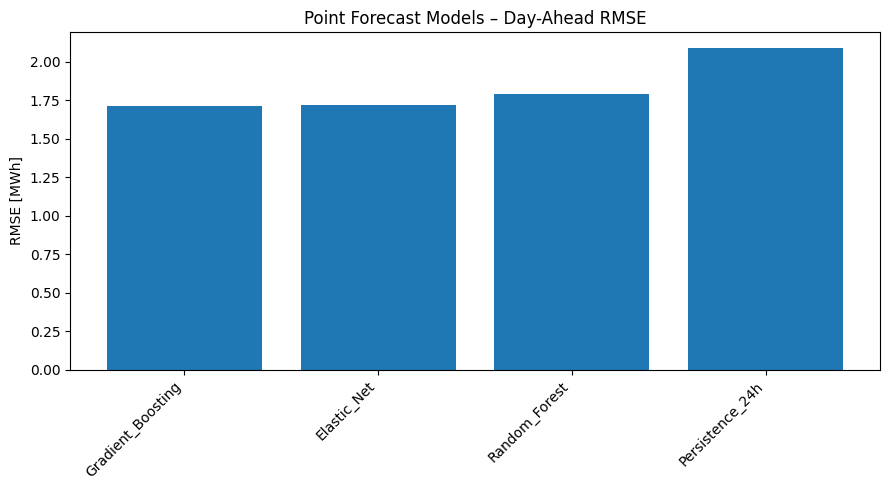

In [ ]:
plot_df = point_metrics.sort_values("RMSE")

plt.figure(figsize=(9, 5))
plt.bar(plot_df["model"], plot_df["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE [MWh]")
plt.title("Point Forecast Models – Day-Ahead RMSE")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "point_forecast_rmse_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()


# Teil B – Probabilistic Forecast Models

Probabilistische Modelle liefern mehrere Quantile pro Zeitpunkt.

Für das Newsvendor-Bidding ist das besonders relevant, weil je nach Kostenstruktur unterschiedliche Quantile als Gebot verwendet werden können.


## 10. Probabilistische Modelle trainieren

In [ ]:

QUANTILES = (0.1, 0.25, 0.5, 0.75, 0.9)

prob_median_metrics_rows = []
pinball_rows = []

# Quantile Regression
qr_models = quantile_regression.train(
    X_train,
    y_train,
    quantiles=QUANTILES,
)
qr_preds = quantile_regression.predict_all(qr_models, X_test)
qr_preds = enforce_quantile_monotonicity(qr_preds).clip(lower=0)
check_quantile_monotonicity(qr_preds, "Quantile Regression")

y_pred_qr_q50 = qr_preds["q50"].to_numpy()
add_point_metrics(prob_median_metrics_rows, "Quantile_Regression_q50", y_test, y_pred_qr_q50)

qr_pinball = quantile_regression.evaluate_quantiles(y_test, qr_preds)
qr_pinball["model"] = "Quantile_Regression"
pinball_rows.append(qr_pinball)

# Quantile Regression Forest
qrf_model = quantile_regression_forest.train(
    X_train,
    y_train,
    n_estimators=300,
    min_samples_leaf=5,
    random_state=42,
)
qrf_preds = quantile_regression_forest.predict_all(
    qrf_model,
    X_test,
    quantiles=QUANTILES,
)
qrf_preds = enforce_quantile_monotonicity(qrf_preds).clip(lower=0)
check_quantile_monotonicity(qrf_preds, "QRF")

y_pred_qrf_q50 = qrf_preds["q50"].to_numpy()
add_point_metrics(prob_median_metrics_rows, "QRF_q50", y_test, y_pred_qrf_q50)

qrf_pinball = quantile_regression_forest.evaluate_quantiles(y_test, qrf_preds)
qrf_pinball["model"] = "QRF"
pinball_rows.append(qrf_pinball)

# Quantile Gradient Boosting
qgb_models = quantile_gradient_boosting.train(
    X_train, y_train,
    quantiles=QUANTILES,
    n_estimators=100,
    learning_rate=0.03,
    max_depth=2,
    min_samples_leaf=20,
)
qgb_preds = quantile_gradient_boosting.predict_all(qgb_models, X_test)
qgb_preds = enforce_quantile_monotonicity(qgb_preds).clip(lower=0)
check_quantile_monotonicity(qgb_preds, "Quantile Gradient Boosting")

y_pred_qgb_q50 = qgb_preds["q50"].to_numpy()
add_point_metrics(prob_median_metrics_rows, "Quantile_Gradient_Boosting_q50", y_test, y_pred_qgb_q50)

qgb_pinball = quantile_gradient_boosting.evaluate_quantiles(y_test, qgb_preds)
qgb_pinball["model"] = "Quantile_Gradient_Boosting"
pinball_rows.append(qgb_pinball)

#quantile xgboost
qxgb_models = quantile_xgboost.train(
    X_train, y_train,
    quantiles=QUANTILES,      
    n_estimators=100,
    learning_rate=0.03,
    max_depth=2,
    min_child_weight=20,
    random_state=42,
)
 
qxgb_preds  = quantile_xgboost.predict_all(qxgb_models, X_test)
qxgb_preds = enforce_quantile_monotonicity(qxgb_preds).clip(lower=0)
check_quantile_monotonicity(qxgb_preds, "Quantile_XGBoost")

 
y_pred_qxgb_q50 = qxgb_preds["q50"].to_numpy()
add_point_metrics(prob_median_metrics_rows, "Quantile_XGBoost_q50", y_test, y_pred_qxgb_q50)
 
pinball_qxgb = quantile_xgboost.evaluate_quantiles(y_test, qxgb_preds)
pinball_qxgb["model"] = "Quantile_XGBoost"
pinball_rows.append(pinball_qxgb)


# Quantile Neural Network
qnn_model = quantile_neural_network.train(
    X_train,
    y_train,
    quantiles=QUANTILES,
    hidden_layer_sizes=(64, 32),
    dropout=0.1,
    learning_rate=0.001,
    weight_decay=0.0001,
    batch_size=64,
    max_epochs=500,
    patience=30,
    random_state=42,
)
qnn_preds = quantile_neural_network.predict_all(qnn_model, X_test)
qnn_preds = enforce_quantile_monotonicity(qnn_preds).clip(lower=0)
check_quantile_monotonicity(qnn_preds, "Quantile Neural Network")

y_pred_qnn_q50 = qnn_preds["q50"].to_numpy()
add_point_metrics(prob_median_metrics_rows, "Quantile_Neural_Network_q50", y_test, y_pred_qnn_q50)

qnn_pinball = quantile_neural_network.evaluate_quantiles(y_test, qnn_preds)
qnn_pinball["model"] = "Quantile_Neural_Network"
pinball_rows.append(qnn_pinball)

prob_median_metrics = pd.DataFrame(prob_median_metrics_rows).sort_values("RMSE")
pinball_metrics = pd.concat(pinball_rows, ignore_index=True)
pinball_metrics = pinball_metrics[["model", "quantile", "pinball_loss"]]

prob_median_metrics


Quantile Regression: quantiles are monotonic.
QRF: quantiles are monotonic.
Quantile Gradient Boosting: quantiles are monotonic.
Quantile Neural Network: quantiles are monotonic.


,model,MAE,RMSE,R2
3,Quantile_Neural_Network_q50,1.185616,1.763668,0.149509
2,Quantile_Gradient_Boosting_q50,1.181080,1.788822,0.125075
0,Quantile_Regression_q50,1.185935,1.790364,0.123566
1,QRF_q50,1.275882,1.830799,0.083532


## 11. Pinball Loss der probabilistischen Modelle

In [ ]:
pinball_metrics.sort_values(["quantile", "pinball_loss"])


,model,quantile,pinball_loss
0,Quantile_Regression,0.10,0.154089
10,Quantile_Gradient_Boosting,0.10,0.154180
15,Quantile_Neural_Network,0.10,0.155704
5,QRF,0.10,0.175831
11,Quantile_Gradient_Boosting,0.25,0.358195
1,Quantile_Regression,0.25,0.359401
16,Quantile_Neural_Network,0.25,0.361941
6,QRF,0.25,0.403742
12,Quantile_Gradient_Boosting,0.50,0.590540
17,Quantile_Neural_Network,0.50,0.592808


## 12. Deskriptive Grafik: Pinball Loss

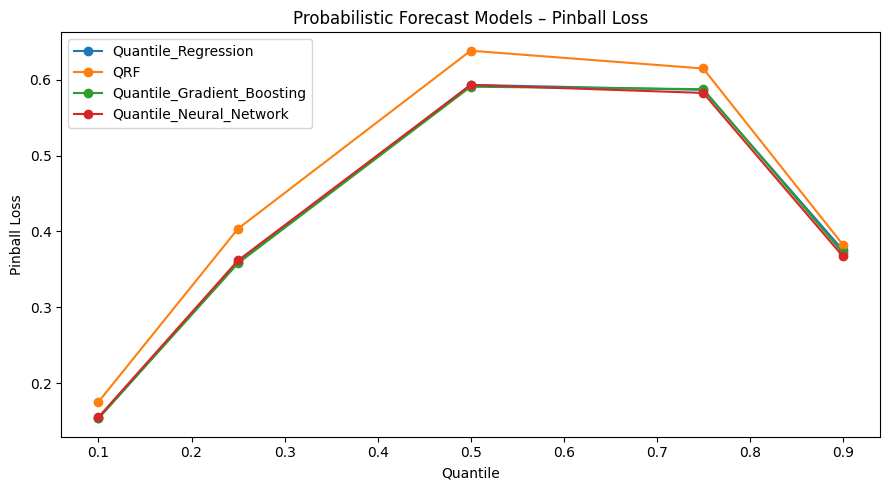

In [ ]:
plt.figure(figsize=(9, 5))

for model_name in pinball_metrics["model"].unique():
    subset = pinball_metrics[pinball_metrics["model"] == model_name].sort_values("quantile")
    plt.plot(
        subset["quantile"],
        subset["pinball_loss"],
        marker="o",
        label=model_name,
    )

plt.xlabel("Quantile")
plt.ylabel("Pinball Loss")
plt.title("Probabilistic Forecast Models – Pinball Loss")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "probabilistic_pinball_loss_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()


## 13. Beispielgrafik: Quantile-Band

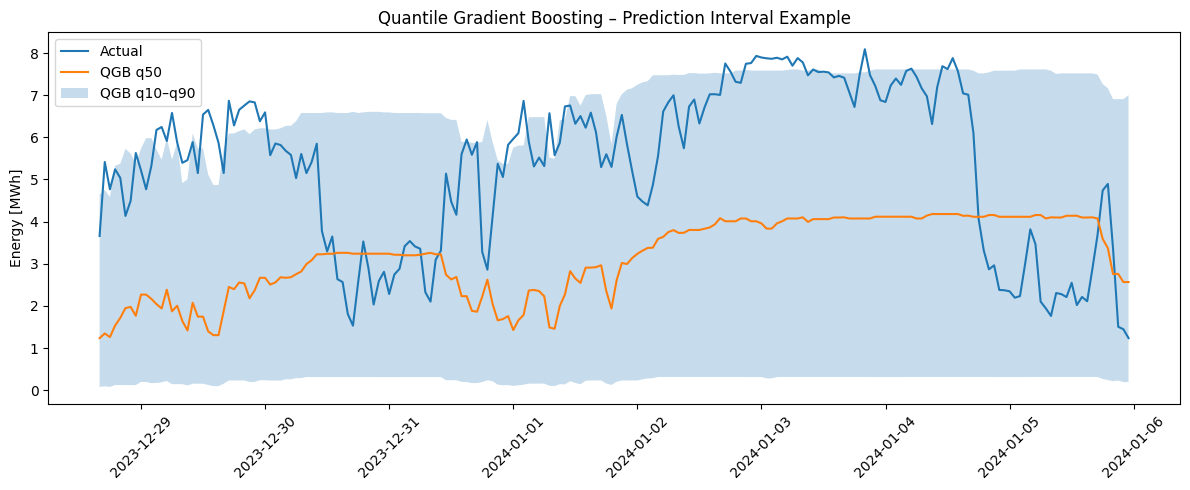

In [ ]:
plot_window = min(200, len(y_test))

plot_data = pd.DataFrame({
    "timestamp": test_timestamps.iloc[:plot_window],
    "actual": y_test.iloc[:plot_window].to_numpy(),
    "q10": qgb_preds["q10"].iloc[:plot_window].to_numpy(),
    "q50": qgb_preds["q50"].iloc[:plot_window].to_numpy(),
    "q90": qgb_preds["q90"].iloc[:plot_window].to_numpy(),
})

plt.figure(figsize=(12, 5))
plt.plot(plot_data["timestamp"], plot_data["actual"], label="Actual")
plt.plot(plot_data["timestamp"], plot_data["q50"], label="QGB q50")
plt.fill_between(
    plot_data["timestamp"],
    plot_data["q10"],
    plot_data["q90"],
    alpha=0.25,
    label="QGB q10–q90",
)

plt.xticks(rotation=45)
plt.ylabel("Energy [MWh]")
plt.title("Quantile Gradient Boosting – Prediction Interval Example")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "qgb_prediction_interval_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()


# Teil C – Gemeinsame Forecast Outputs

## 14. Gemeinsames Predictions-DataFrame erstellen

In [ ]:
predictions = pd.DataFrame({
    "timestamp": test_timestamps.values,
    "y_true": y_test.to_numpy(),

    "persistence_24h": y_pred_persistence_24h,
    "arima": y_pred_arima,
    "elastic_net": y_pred_elastic_net,
    "random_forest": y_pred_random_forest,
    "gradient_boosting": y_pred_gradient_boosting,
    "xgboost": y_pred_xgboost,

    "quantile_regression_q10": qr_preds["q10"].to_numpy(),
    "quantile_regression_q25": qr_preds["q25"].to_numpy(),
    "quantile_regression_q50": qr_preds["q50"].to_numpy(),
    "quantile_regression_q75": qr_preds["q75"].to_numpy(),
    "quantile_regression_q90": qr_preds["q90"].to_numpy(),

    "qrf_q10": qrf_preds["q10"].to_numpy(),
    "qrf_q25": qrf_preds["q25"].to_numpy(),
    "qrf_q50": qrf_preds["q50"].to_numpy(),
    "qrf_q75": qrf_preds["q75"].to_numpy(),
    "qrf_q90": qrf_preds["q90"].to_numpy(),

    "qgb_q10": qgb_preds["q10"].to_numpy(),
    "qgb_q25": qgb_preds["q25"].to_numpy(),
    "qgb_q50": qgb_preds["q50"].to_numpy(),
    "qgb_q75": qgb_preds["q75"].to_numpy(),
    "qgb_q90": qgb_preds["q90"].to_numpy(),

    "qxgb_q10": qxgb_preds["q10"].to_numpy(),
    "qxgb_q25": qxgb_preds["q25"].to_numpy(),
    "qxgb_q50": qxgb_preds["q50"].to_numpy(),
    "qxgb_q75": qxgb_preds["q75"].to_numpy(),
    "qxgb_q90": qxgb_preds["q90"].to_numpy(),

    "qnn_q10": qnn_preds["q10"].to_numpy(),
    "qnn_q25": qnn_preds["q25"].to_numpy(),
    "qnn_q50": qnn_preds["q50"].to_numpy(),
    "qnn_q75": qnn_preds["q75"].to_numpy(),
    "qnn_q90": qnn_preds["q90"].to_numpy(),
})

print(predictions.shape)
predictions.head()


(14434, 26)


,timestamp,y_true,persistence_24h,elastic_net,random_forest,gradient_boosting,quantile_regression_q10,quantile_regression_q25,quantile_regression_q50,quantile_regression_q75,...,qgb_q10,qgb_q25,qgb_q50,qgb_q75,qgb_q90,qnn_q10,qnn_q25,qnn_q50,qnn_q75,qnn_q90
0,2023-12-28 16:00:00,3.658817,2.478517,1.975756,2.466138,2.017057,0.149813,0.592765,1.522907,2.898745,...,0.077003,0.389512,1.234058,3.052345,4.641395,0.107159,0.473328,1.551906,3.407467,5.661342
1,2023-12-28 17:00:00,5.413850,2.896417,2.092140,2.861270,2.114102,0.164671,0.664564,1.699550,3.137665,...,0.090251,0.422108,1.345555,3.310469,4.751658,0.119742,0.530830,1.698599,3.597483,5.809386
2,2023-12-28 18:00:00,4.764850,2.401433,1.964446,2.741215,2.022536,0.140769,0.576974,1.537309,2.951098,...,0.077003,0.389512,1.258877,3.052345,4.584227,0.098622,0.456237,1.533408,3.372171,5.575914
3,2023-12-28 19:00:00,5.240700,3.118417,2.195746,3.339252,2.379958,0.172555,0.723185,1.881009,3.413219,...,0.121240,0.541267,1.534552,3.423380,5.324251,0.119505,0.540396,1.754359,3.704581,5.896407
4,2023-12-28 20:00:00,5.035000,3.621133,2.297645,3.733128,2.454176,0.184312,0.779478,2.007120,3.592152,...,0.121240,0.617369,1.715745,3.760980,5.374555,0.140909,0.632366,1.981164,4.024418,6.245234


## 15. Beispielgrafik: Actual vs. ausgewählte Forecasts

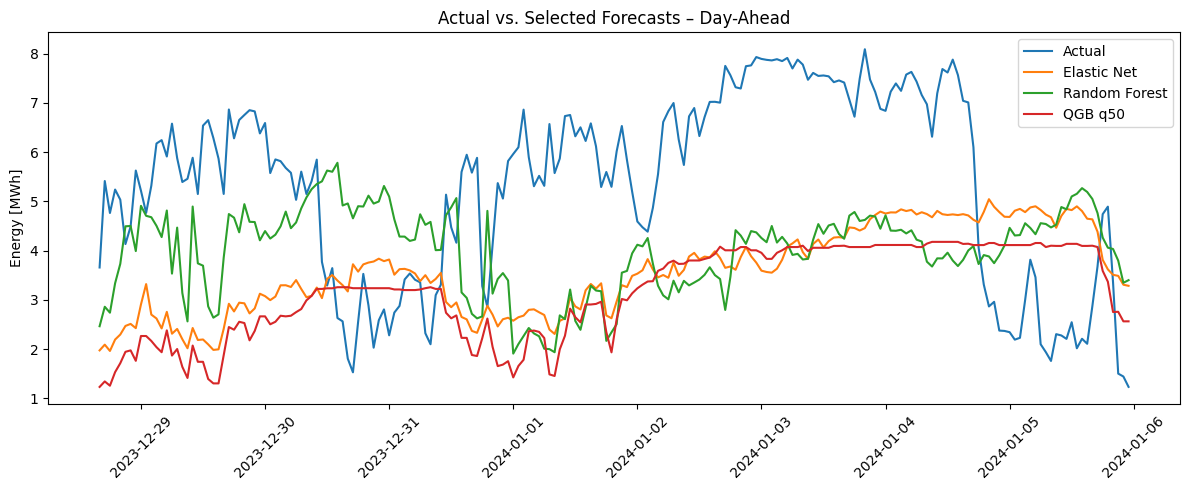

In [ ]:
plot_window = min(200, len(predictions))

plt.figure(figsize=(12, 5))

plt.plot(
    predictions["timestamp"].iloc[:plot_window],
    predictions["y_true"].iloc[:plot_window],
    label="Actual",
)

plt.plot(
    predictions["timestamp"].iloc[:plot_window],
    predictions["persistence_24h"].iloc[:plot_window],
    label="Persistence 24h",
)

plt.plot(
    predictions["timestamp"].iloc[:plot_window],
    predictions["arima"].iloc[:plot_window],   
    label="ARIMA",
)

plt.plot(
    predictions["timestamp"].iloc[:plot_window],
    predictions["elastic_net"].iloc[:plot_window],
    label="Elastic Net",
)

plt.plot(
    predictions["timestamp"].iloc[:plot_window],
    predictions["random_forest"].iloc[:plot_window],
    label="Random Forest",
)

plt.plot(
    predictions["timestamp"].iloc[:plot_window],
    predictions["qgb_q50"].iloc[:plot_window],
    label="QGB q50",
)

plt.plot(
    predictions["timestamp"].iloc[:plot_window],
    predictions["qxgb_q50"].iloc[:plot_window],
    label="QXGB q50",
)

plt.xticks(rotation=45)
plt.ylabel("Energy [MWh]")
plt.title("Actual vs. Selected Forecasts – Day-Ahead")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "actual_vs_selected_forecasts_day_ahead.png", dpi=300, bbox_inches="tight")
plt.show()


## Hinweis zu xAI

Die erklärende Analyse der Modelle erfolgt nicht in diesem Forecasting-Notebook, sondern in Notebook 05.

Dort sollten insbesondere folgende Aspekte betrachtet werden:

- Koeffizienten von Elastic Net als interpretierbares Modell
- Feature Importances und SHAP für Random Forest, Gradient Boosting, QRF und Quantile Gradient Boosting
- Analyse von Zeitpunkten mit hohen Bidding-Verlusten aus Notebook 04

Notebook 03 erzeugt dafür nur die Forecasts, Modelle und Testfeatures.


## 16. Outputs speichern

In [ ]:
predictions_path = FORECAST_DIR / "predictions_day_ahead.csv"
features_path = FORECAST_DIR / "test_features_day_ahead.csv"

point_metrics_path = TABLES_DIR / "point_forecast_metrics_day_ahead.csv"
prob_median_metrics_path = TABLES_DIR / "probabilistic_median_metrics_day_ahead.csv"
pinball_metrics_path = TABLES_DIR / "pinball_metrics_day_ahead.csv"

predictions.to_csv(predictions_path, index=False)
X_test.reset_index(drop=True).to_csv(features_path, index=False)

point_metrics.to_csv(point_metrics_path, index=False)
prob_median_metrics.to_csv(prob_median_metrics_path, index=False)
pinball_metrics.to_csv(pinball_metrics_path, index=False)

print("Saved:", predictions_path)
print("Saved:", features_path)
print("Saved:", point_metrics_path)
print("Saved:", prob_median_metrics_path)
print("Saved:", pinball_metrics_path)


Saved: /Users/noahweis/wind_bidding_project/results/forecasts/predictions_day_ahead.csv
Saved: /Users/noahweis/wind_bidding_project/results/forecasts/test_features_day_ahead.csv
Saved: /Users/noahweis/wind_bidding_project/results/tables/point_forecast_metrics_day_ahead.csv
Saved: /Users/noahweis/wind_bidding_project/results/tables/probabilistic_median_metrics_day_ahead.csv
Saved: /Users/noahweis/wind_bidding_project/results/tables/pinball_metrics_day_ahead.csv


## 17. Modelle speichern

In [ ]:
joblib.dump(ar_model, MODELS_DIR / "arima_day_ahead.joblib")
joblib.dump(en_model, MODELS_DIR / "elastic_net_day_ahead.joblib")
joblib.dump(rf_model, MODELS_DIR / "random_forest_day_ahead.joblib")
joblib.dump(gb_model, MODELS_DIR / "gradient_boosting_day_ahead.joblib")
joblib.dump(xgb_model, MODELS_DIR / "xgboost_day_ahead.joblib")

joblib.dump(qr_models, MODELS_DIR / "quantile_regression_day_ahead.joblib")
joblib.dump(qrf_model, MODELS_DIR / "qrf_day_ahead.joblib")
joblib.dump(qgb_models, MODELS_DIR / "quantile_gradient_boosting_day_ahead.joblib")
joblib.dump(qxgb_models, MODELS_DIR / "quantile_xgboost_day_ahead.joblib")
joblib.dump(qnn_model, MODELS_DIR / "quantile_neural_network_day_ahead.joblib")

print("Saved models to:", MODELS_DIR)


Saved models to: /Users/noahweis/wind_bidding_project/results/models


## 18. Zusammenfassung

In [ ]:
print("Point Forecast Metrics")
display(point_metrics)

print("Probabilistic Median Metrics")
display(prob_median_metrics)

print("Pinball Metrics")
display(pinball_metrics.sort_values(["quantile", "pinball_loss"]))


Point Forecast Metrics


,model,MAE,RMSE,R2
3,Gradient_Boosting,1.307396,1.713181,0.197504
1,Elastic_Net,1.293965,1.719325,0.191738
2,Random_Forest,1.359759,1.792325,0.121646
0,Persistence_24h,1.397220,2.087777,-0.191803


Probabilistic Median Metrics


,model,MAE,RMSE,R2
3,Quantile_Neural_Network_q50,1.185616,1.763668,0.149509
2,Quantile_Gradient_Boosting_q50,1.181080,1.788822,0.125075
0,Quantile_Regression_q50,1.185935,1.790364,0.123566
1,QRF_q50,1.275882,1.830799,0.083532


Pinball Metrics


,model,quantile,pinball_loss
0,Quantile_Regression,0.10,0.154089
10,Quantile_Gradient_Boosting,0.10,0.154180
15,Quantile_Neural_Network,0.10,0.155704
5,QRF,0.10,0.175831
11,Quantile_Gradient_Boosting,0.25,0.358195
1,Quantile_Regression,0.25,0.359401
16,Quantile_Neural_Network,0.25,0.361941
6,QRF,0.25,0.403742
12,Quantile_Gradient_Boosting,0.50,0.590540
17,Quantile_Neural_Network,0.50,0.592808
